<a href="https://colab.research.google.com/github/BALMEETCHADHA/STOCKS_ANALYSIS/blob/main/STOCK_MARKET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data

In [110]:
import yfinance as yf

In [111]:
start = '2019-01-01'
end = '2024-01-01'

df = yf.download('AAPL', start=start, end=end, auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768074,34.606398,33.722951,34.193172,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131248,35.344988,34.649153,35.314113,219111200
2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200


In [112]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-12-22,191.609451,193.400839,190.985924,193.173193,37149600
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300
2023-12-27,191.164108,191.510516,189.125291,190.510906,48087700
2023-12-28,191.589676,192.658574,191.183888,192.143916,34049900
2023-12-29,190.550491,192.401260,189.758714,191.906401,42672100


In [113]:
# Flatten MultiIndex columns to a single level for easier access
df.columns = df.columns.get_level_values('Price')

# Reset the index to make 'Date' a regular column
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
1,2019-01-03,33.768074,34.606398,33.722951,34.193172,365248800
2,2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
3,2019-01-07,35.131248,35.344988,34.649153,35.314113,219111200
4,2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200


In [114]:
print(df.columns)

# 'Date' column is now handled and 'Adj Close' is usually not present with auto_adjust=True.
# Ensure columns exist before attempting to drop them
columns_to_drop = ['Date', 'Adj Close']
cols_to_drop_actual = [col for col in columns_to_drop if col in df.columns]

if cols_to_drop_actual:
    df = df.drop(cols_to_drop_actual, axis=1)

df.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Close,High,Low,Open,Volume
0,37.503723,37.724587,36.627401,36.784142,148158800
1,33.768074,34.606398,33.722951,34.193172,365248800
2,35.209614,35.278487,34.150430,34.323794,234428400
3,35.131248,35.344988,34.649153,35.314113,219111200
4,35.800957,36.055068,35.271365,35.518348,164101200


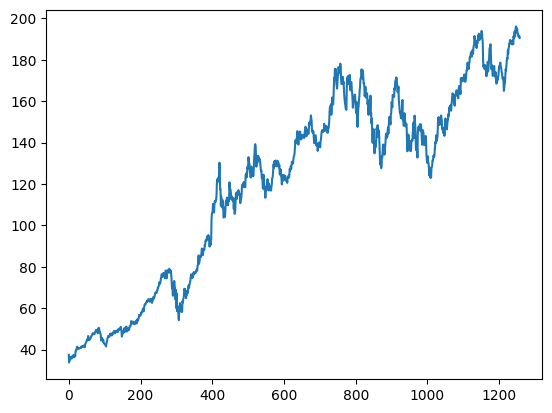

In [115]:
plt.plot(df.Close)

In [116]:
ma100=df.Close.rolling(100).mean()
ma100

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1253,179.723260
1254,179.746904
1255,179.862153
1256,180.012651


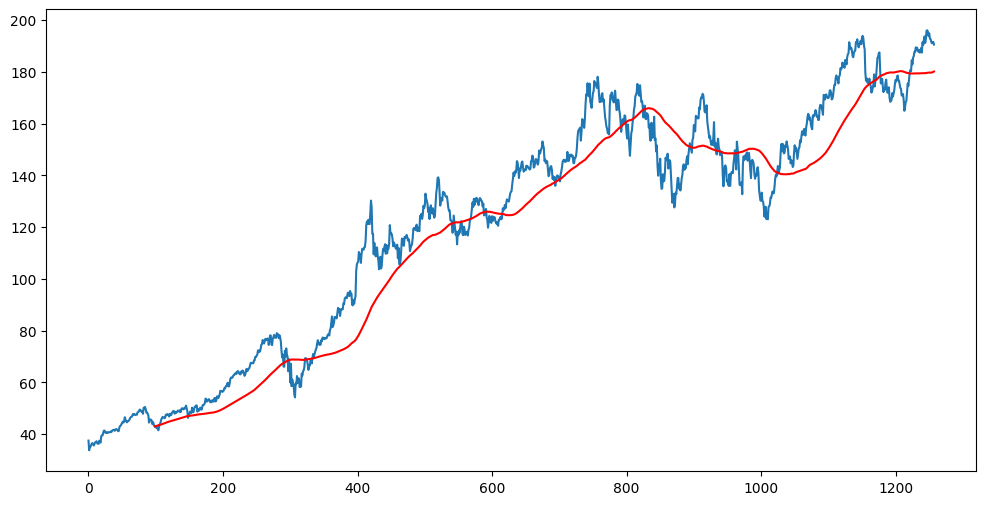

In [117]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [118]:
ma200=df.Close.rolling(200).mean()
ma200

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1253,176.443947
1254,176.667375
1255,176.881590
1256,177.087483


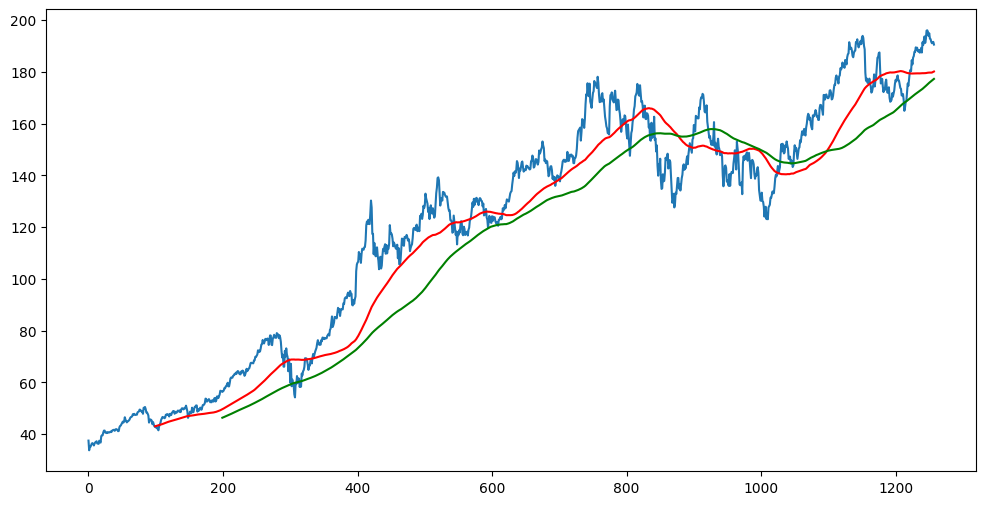

In [119]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'g')

In [120]:
df.shape

(1258, 5)

In [121]:
#Splitting Data into Training and Testing

data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(880, 1)
(378, 1)


In [122]:
data_training.head()

,Close
0,37.503723
1,33.768074
2,35.209614
3,35.131248
4,35.800957


In [123]:
data_testing.head()

,Close
880,134.152985
881,136.321457
882,138.902084
883,140.236542
884,143.602142


In [124]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [125]:
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.02588169],
       [0.        ],
       [0.00998742],
       [0.00944448],
       [0.01408442],
       [0.01829652],
       [0.01910277],
       [0.01661828],
       [0.01285041],
       [0.01790172],
       [0.02097854],
       [0.02249226],
       [0.02407184],
       [0.01828013],
       [0.01930023],
       [0.01729286],
       [0.02561848],
       [0.02321619],
       [0.02055071],
       [0.03794226],
       [0.03990028],
       [0.04003189],
       [0.0478145 ],
       [0.05263542],
       [0.05273419],
       [0.04730446],
       [0.04763496],
       [0.04601555],
       [0.04842811],
       [0.04725488],
       [0.04827936],
       [0.04765143],
       [0.04849413],
       [0.05031191],
       [0.04870892],
       [0.05186517],
       [0.05394722],
       [0.0541124 ],
       [0.05500474],
       [0.05216257],
       [0.05517   ],
       [0.05662419],
       [0.05609537],
       [0.05442646],
       [0.05108843],
       [0.05176598],
       [0.06166409],
       [0.064

In [126]:
x_train=[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train=np.array(x_train),np.array(y_train)

In [127]:
#ML Model

from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential

In [128]:
model=Sequential()
model.add(LSTM(units=50,activation='relu',return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation='relu',return_sequences=True,))
model.add(Dropout(0.3))

model.add(LSTM(units=80,activation='relu',return_sequences=True,))
model.add(Dropout(0.4))

model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [129]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [130]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step - loss: 0.1171
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0253
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0162
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0131
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0117
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0113
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0109
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0112
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0104
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0100
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0099
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0094
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0104
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0136
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0100
Ep

In [131]:
model.save('keras_model.h5')

In [132]:
past_100_days=data_training.tail(100)

In [133]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [134]:
final_df.head()

,Close
0,168.905029
1,168.189819
2,171.295731
3,172.716400
4,168.640518


In [135]:
input_data = scaler.fit_transform(final_df)
input_data

array([[6.27968607e-01],
       [6.18174739e-01],
       [6.60706146e-01],
       [6.80160364e-01],
       [6.24346472e-01],
       [5.77655930e-01],
       [5.80875838e-01],
       [6.33335468e-01],
       [6.30115769e-01],
       [5.80875838e-01],
       [5.59676893e-01],
       [5.19694876e-01],
       [4.62673466e-01],
       [4.98496349e-01],
       [5.26805836e-01],
       [5.30428180e-01],
       [5.04667874e-01],
       [5.49748880e-01],
       [5.45321036e-01],
       [5.04265437e-01],
       [4.52342389e-01],
       [4.27386328e-01],
       [5.01313612e-01],
       [4.41876958e-01],
       [3.91026863e-01],
       [3.35883489e-01],
       [3.95856725e-01],
       [4.56233024e-01],
       [4.70052299e-01],
       [5.15132887e-01],
       [5.33917005e-01],
       [5.80070756e-01],
       [5.98720520e-01],
       [6.50509006e-01],
       [6.59230129e-01],
       [6.71037223e-01],
       [7.16118020e-01],
       [7.00151791e-01],
       [6.57754320e-01],
       [6.53728913e-01],


In [136]:
input_data.shape

(478, 1)

In [137]:
x_test=[]
y_test=[]

for i in range(100 , input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [138]:
x_test,y_test=np.array(x_test),np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(378, 100, 1)
(378,)


In [139]:
#Making Predictions

y_predicted=model.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step


In [140]:
y_predicted.shape

(378, 1)

In [141]:
y_test

array([1.52084639e-01, 1.81779042e-01, 2.17117372e-01, 2.35391027e-01,
       2.81478541e-01, 2.90750037e-01, 2.61592425e-01, 2.74894551e-01,
       2.69923022e-01, 3.09963964e-01, 3.32806294e-01, 2.91153100e-01,
       3.43958959e-01, 3.71369337e-01, 4.02407492e-01, 3.85477798e-01,
       3.70160148e-01, 3.52021056e-01, 4.21756609e-01, 4.29281080e-01,
       4.98613779e-01, 4.85176880e-01, 4.65022264e-01, 5.47254235e-01,
       5.42954477e-01, 5.39859939e-01, 5.33401527e-01, 5.34074135e-01,
       5.92200886e-01, 5.82109474e-01, 6.30682440e-01, 6.45348586e-01,
       6.43196200e-01, 6.63647942e-01, 6.58266037e-01, 6.22878604e-01,
       5.69730486e-01, 5.65155542e-01, 5.69192024e-01, 6.02830552e-01,
       5.16582159e-01, 4.86442486e-01, 4.53208274e-01, 4.30468956e-01,
       4.40425387e-01, 4.11496575e-01, 3.94274143e-01, 4.13515233e-01,
       3.93331991e-01, 4.32486779e-01, 5.14025665e-01, 3.84989693e-01,
       4.04769245e-01, 3.65210559e-01, 3.42740367e-01, 3.93601118e-01,
      

In [142]:
scaler.scale_
a=scaler.scale_
a

array([0.0136937])

In [143]:
scale_factor=1/a
y_predicted=y_predicted*scale_factor
y_test=y_test*scale_factor

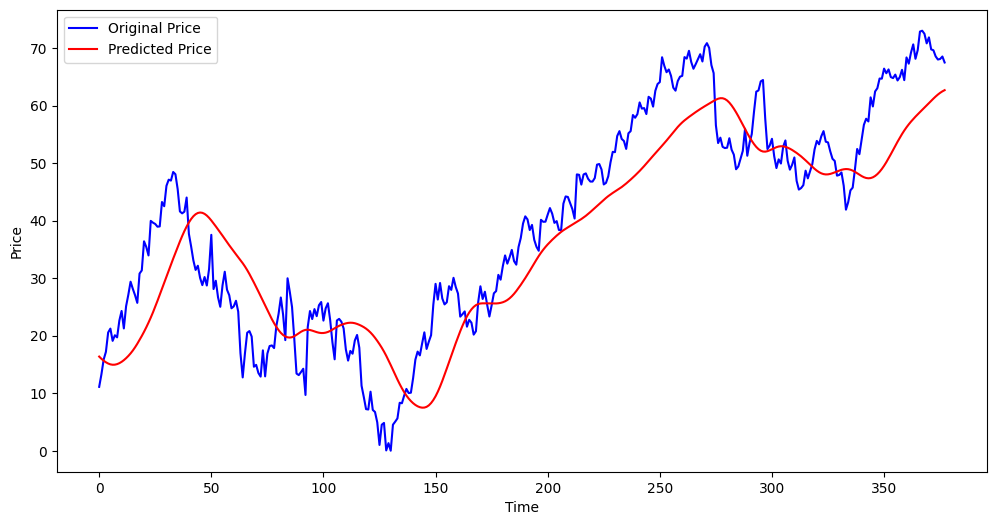

In [144]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()